# Creating a neural network

In [13]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import shap
from pathlib import Path

from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

graph_dir = Path("graphs")

In [2]:
%store -r songs
%store -r features

In [3]:
X = songs[features].values
y = songs['new_taylor'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=13)

Our neural network consists of three Dense (Fully Connected) layers built on top of an input layer. For the two hidden layers, we use the **ReLU activation function** to learn complex patterns. The final layer uses a Sigmoid activation function to output a confidence score between 0 and 1 (0–100%). For this model we are using one of the most popular optimizers - **Adaptive Moment Estimation** (adam) with **binary_crossentropy loss function**. The loss function is used to make sure that we don't make mistakes - the bigger the misscalculation, the harsher the punishment. 


In [4]:
input_shape = (len(features),)
early_stopping_monitor = EarlyStopping(patience=5, restore_best_weights=True)

model = Sequential()
model.add(Input(shape=input_shape))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.fit(X_train, y_train,
          validation_data=(X_test, y_test),
          epochs=30,
          callbacks=[early_stopping_monitor],
          verbose=0)

Saving the model

In [5]:
model.save('../models/new_taylor_NN.keras')
joblib.dump(scaler, '../models/scaler_NN.joblib')

['../models/scaler_NN.joblib']

### Comparing the results

In [6]:
y_pred_test = model.predict(X_test)
y_pred_prob_test = y_pred_test > 0.5

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


In [7]:
print(confusion_matrix(y_test, y_pred_prob_test))

[[11  3]
 [ 4 22]]


In [8]:
print(classification_report(y_test, y_pred_prob_test))

              precision    recall  f1-score   support

       False       0.73      0.79      0.76        14
        True       0.88      0.85      0.86        26

    accuracy                           0.82        40
   macro avg       0.81      0.82      0.81        40
weighted avg       0.83      0.82      0.83        40



The Neural Network made fewer mistakes compared to the KNN model and scored higher on every single metric. The most impressive jump is from KNN's 0.65 precision for False (old taylor) to 0.85 for the Neural Network. 

### Pinpointing the incorrect guesses

In [9]:
y_pred_prob = model.predict(X_scaled)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

results = pd.DataFrame({
    'Song': songs.index,
    'Actual': y,
    'Predicted': y_pred,
    'Confidence': y_pred_prob.flatten()
})

errors = results[results['Actual'] != results['Predicted']]
display(errors[['Song', 'Actual', 'Predicted', 'Confidence']].sort_values('Confidence', ascending=False).head(5))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


,Song,Actual,Predicted,Confidence
166,Forever & Always - Piano Version,False,1,0.965067
145,Sad Beautiful Tragic,False,1,0.954690
157,Never Grow Up,False,1,0.933316
132,You Are In Love,False,1,0.853637
181,The Best Day,False,1,0.813923


We can see that 5 songs that were misstakenly assigned are all old era songs classified as new era songs, with confidence higher than 0.8. This might be because all of those songs are ballads with a slow tempo. Old era has songs such as *Shake It Off*, *Haunted* that are popular because of their energy and danceability. With Taylor's career progression the themes became more mature and the songs slower, so the ballads of 2000s and 2010s were classified as new.

Though we can guess the reasoning we can use Explainable AI to try to unbox why the model made those decisions.

In [10]:
explainer = shap.Explainer(model.predict, X_train)
shap_values = explainer(X_test)

400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 767us/step
398/398 ━━━━━━━━━━━━━━━━━━━━ 0s 780us/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 776us/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 764us/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


ExactExplainer explainer:  10%|██████▌                                                          | 4/40 [00:00<?, ?it/s]

400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 767us/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


ExactExplainer explainer:  15%|████████▌                                                | 6/40 [00:11<00:13,  2.45it/s]

400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 872us/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


...

ExactExplainer explainer:  98%|██████████████████████████████████████████████████████▌ | 39/40 [00:36<00:00,  1.25it/s]

398/398 ━━━━━━━━━━━━━━━━━━━━ 0s 751us/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


ExactExplainer explainer: 100%|████████████████████████████████████████████████████████| 40/40 [00:37<00:00,  1.24it/s]

400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 819us/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


ExactExplainer explainer: 41it [00:37,  1.03s/it]                                                                      


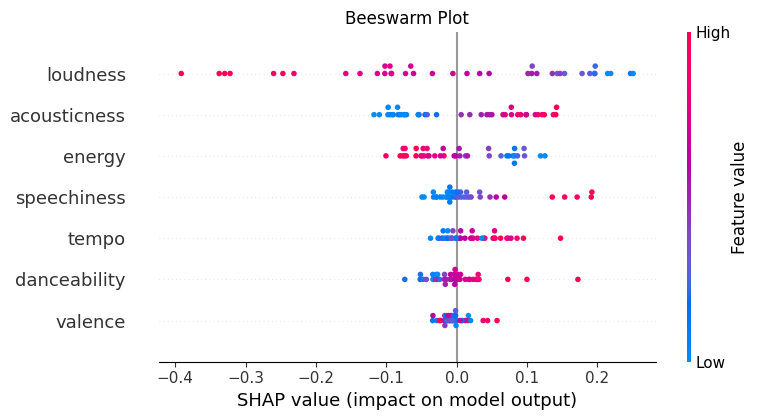

In [14]:
shap_values.feature_names = features
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values, show=False)
plt.title("Beeswarm Plot")
plt.tight_layout()
plt.savefig(f"{graph_dir}/NN_shap.png")
plt.show()

The two most important categories are loudness and acousticness. Lower loudness and higher accousticness indicate the new era - the guitars and pianos of the *folkore*/*evermore* era seem to be definig. Higher speechiness might also indicate the new era, with less country-roots songs and more modern approach to songwriting, where there are more "spoken" parts. Even though the old era contains the breakout pop album *1989*, new era also has *Lover* and *Midnights*, which might skew some of the danceability results. For the new era we can also see the model favours a higher tempo, lower energy and less positive messages.